# Question 1

Load the data from the file *trajectory.csv*. The data consists of three rows representing a trajectory. The first row represents time, the second row represents the $x$-coordinate at each timestep, and the third row represents the $y$-coordinate.

**Q1 a (3 marks)**

Plot the $x$-coordinate against time (i.e., t-x figure) and also for the $y$-coordinate (i.e., t-y figure). Also plot the trajectory in 2D (i.e., x-y figure).

You need to respectively use variables 't', 'x', 'y' to represent time, x-coordinate, and y-coordinate, as these variables will be needed in other questions.

Include clear titles, axis labels, and legends for all figures.

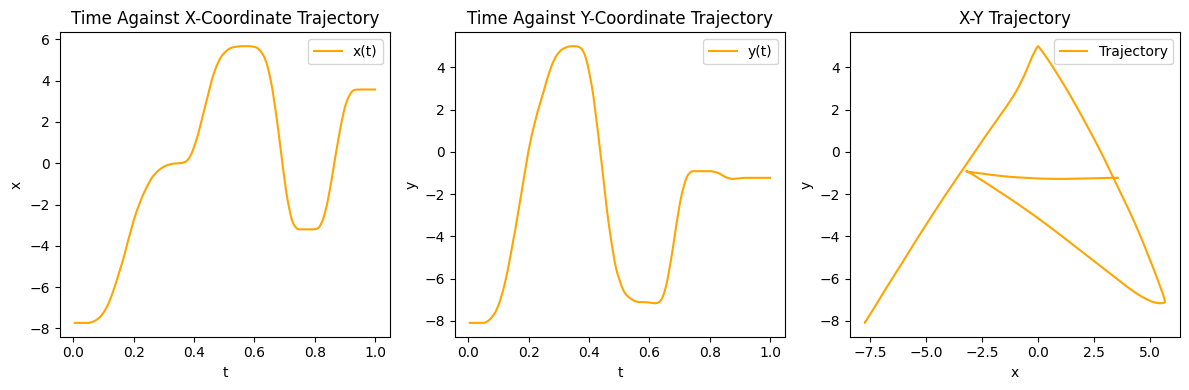

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# read from trajectory.csv
data = np.loadtxt("trajectory.csv", delimiter=",", skiprows=1, usecols=range(1, 201))
t = data[0]
x = data[1]
y = data[2]

# 3 plots on one figure. - x(t), y(t), and x-y trajectory.
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(t, x, label='x(t)', color='orange')
plt.title('Time Against X-Coordinate Trajectory')    
plt.xlabel('t')
plt.ylabel('x')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(t, y, label='y(t)', color='orange')
plt.title('Time Against Y-Coordinate Trajectory')
plt.xlabel('t')
plt.ylabel('y')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(x, y, label='Trajectory', color='orange')
plt.title('X-Y Trajectory')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.tight_layout()
plt.show()


### Linear regression using polynomial basis functions

**Q1 b (6 marks)**

Use your `t`, `x`, and `y` variables from Q1 a.

1. Implement `polynomial_basis_function(t, basis_num)` to return a polynomial design matrix.
2. Use linear regression with your basis function (for Q1 b, use `basis_num = 15`) to fit the 2D trajectory data (`x`, `y`). Note that the bias term should be added in your fitting.
3. Generate predicted trajectories for both coordinates across all time points.
4. Plot and compare on the same axes:
   - original `x` and predicted `x` against `t`,
   - original `y` and predicted `y` against `t`,
   - original and predicted trajectories in the `x-y` plane.

Include clear titles, axis labels, and legends for all figures.

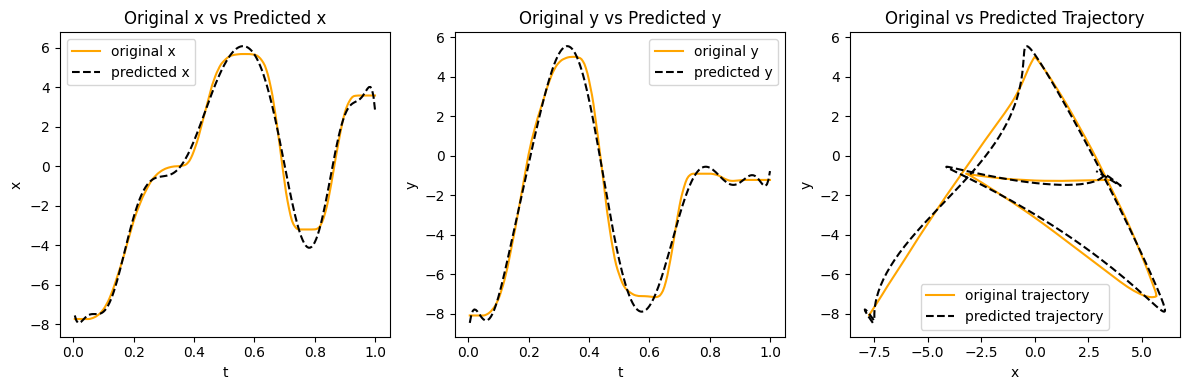

In [55]:
def polynomial_basis_function(t, basis_num):

    # Create an empty design matrix.
    N = np.zeros((len(t), basis_num))
    
    # Fill the design matrix with the polynomial basis functions.
    for i in range(basis_num):
        N[:, i] = t ** i
    
    return N
    
N_15 = polynomial_basis_function(t, 15)

# Use linear regression to fit the data.
def fit_linear_regression(t: np.ndarray, coordinate: np.ndarray, N: np.ndarray, fit_intercept: bool = True) -> np.ndarray:
    # Normal equation: (X^T X) w = X^T y
    A = N.T @ N
    rhs = N.T @ coordinate
    w = np.linalg.solve(A, rhs)

    return w

w_x = fit_linear_regression(t, x, N_15)
w_y = fit_linear_regression(t, y, N_15)

# Generate predicted trajectories for both coordinates across all time points.
def predict_linear_regression(N: np.ndarray, w: np.ndarray, fit_intercept: bool = True) -> np.ndarray:
    return N @ w

x_pred = predict_linear_regression(N_15, w_x)
y_pred = predict_linear_regression(N_15, w_y)
x_y_pred = predict_linear_regression(N_15, w_x, w_y)

# plot and compare on the same axes:
# - original x and predicted x against t,
# - original y and predicted y against t,
# - original and predicted trajectories in the x-y plane.

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(t, x, label='original x', color='orange')
plt.plot(t, x_pred, label='predicted x', linestyle='--', color='black')
plt.title('Original x vs Predicted x')
plt.xlabel('t')
plt.ylabel('x')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(t, y, label='original y', color='orange')
plt.plot(t, y_pred, label='predicted y', linestyle='--', color='black')
plt.title('Original y vs Predicted y')
plt.xlabel('t')
plt.ylabel('y')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(x, y, label='original trajectory', color='orange')
plt.plot(x_pred, y_pred, label='predicted trajectory', linestyle='--', color='black')
plt.title('Original vs Predicted Trajectory')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.tight_layout()
plt.show()

**Q1 c (3 marks)**

Using the polynomial basis model, plot the fitted trajectories for `basis_num = 2, 5, 10` and briefly compare how fit quality changes as the number of basis functions increases.

Include clear titles, axis labels, and legends for all figures.

### Results and Interpretation

Here we analyse the difference in predictions based on polynomial basis functions and their basis num. We can see from the plots that basis_num = 2 is presenting a linear shape. Aswell as basis_num = 5 being too low as well showing not enough change in direction on the line (indicating the value needs to be increased). basis_num = 10 shows a good prediction of trajectory.

Polynomial basis function - 1, t^1, t^2, t^3 ... t^n.
Basis num - In simple terms this is how many 'bend points' to the trajectory.

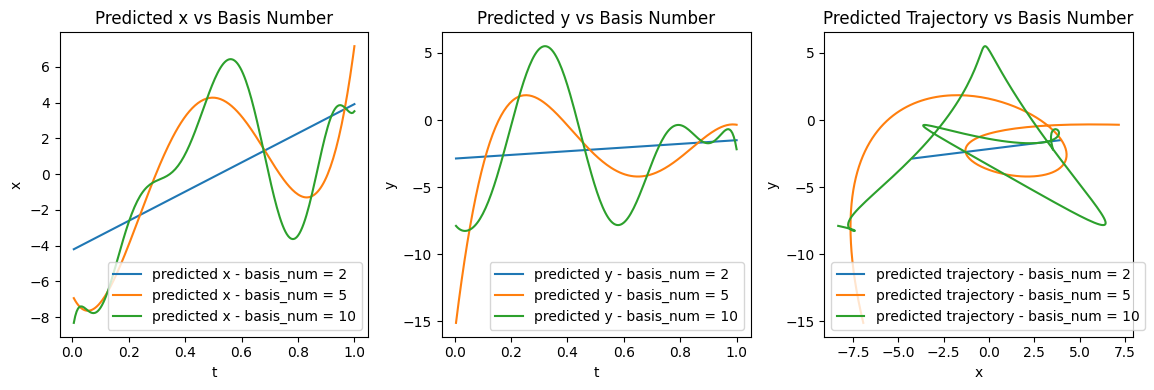

In [56]:
N_2 = polynomial_basis_function(t, 2)
N_5 = polynomial_basis_function(t, 5)
N_10 = polynomial_basis_function(t, 10)

# fit the data
w_x_2 = fit_linear_regression(t, x, N_2)
w_x_5 = fit_linear_regression(t, x, N_5)
w_x_10 = fit_linear_regression(t, x, N_10)

w_y_2 = fit_linear_regression(t, y, N_2)    
w_y_5 = fit_linear_regression(t, y, N_5)
w_y_10 = fit_linear_regression(t, y, N_10)

# generate predicted trajectories for both coordinates across all time points.
x_pred_2 = predict_linear_regression(N_2, w_x_2)
x_pred_5 = predict_linear_regression(N_5, w_x_5)
x_pred_10 = predict_linear_regression(N_10, w_x_10)

y_pred_2 = predict_linear_regression(N_2, w_y_2)
y_pred_5 = predict_linear_regression(N_5, w_y_5)
y_pred_10 = predict_linear_regression(N_10, w_y_10)

x_y_pred_2 = predict_linear_regression(w_x_2, w_y_2)
x_y_pred_5 = predict_linear_regression(w_x_5, w_y_5)
x_y_pred_10 = predict_linear_regression(w_x_10, w_y_10)

# plot the fitted trajectories for `basis_num = 2, 5, 10`
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(t, x_pred_2, label='predicted x - basis_num = 2')
plt.plot(t, x_pred_5, label='predicted x - basis_num = 5')
plt.plot(t, x_pred_10, label='predicted x - basis_num = 10')
plt.title('Predicted x vs Basis Number')
plt.xlabel('t')
plt.ylabel('x')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(t, y_pred_2, label='predicted y - basis_num = 2')
plt.plot(t, y_pred_5, label='predicted y - basis_num = 5')
plt.plot(t, y_pred_10, label='predicted y - basis_num = 10')
plt.title('Predicted y vs Basis Number')
plt.xlabel('t')
plt.ylabel('y')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(x_pred_2, y_pred_2, label='predicted trajectory - basis_num = 2')
plt.plot(x_pred_5, y_pred_5, label='predicted trajectory - basis_num = 5')
plt.plot(x_pred_10, y_pred_10, label='predicted trajectory - basis_num = 10')
plt.title('Predicted Trajectory vs Basis Number')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.tight_layout()
plt.show()


# Question 2

Given a set of basis functions (sine, cosine, exponential, polynomial, and radial basis functions), select and combine appropriate ones to construct a suitable basis function vector for linear regression.

Find the smallest number of basis functions that provides a good fit to the following trajectories.

**Q2 a (5 marks)**

Consider what basis functions might be suitable to model the data in "q2_a_data.npy". In this file, the first column is time t while the second column is the x-coordinate. You should be able to achieve a good fit with a small number of basis functions.

Tasks:
1. Choose and implement your basis function combination. You may decide whether to include a bias term depending on your fitting performance.
2. Plot your prediction and the original data in the same figure (i.e., t-x).
3. Calculate and report the Mean Squared Error (MSE) for your fit.
4. Justify your choice of basis functions.

Include clear titles, axis labels, and legends for all figures.


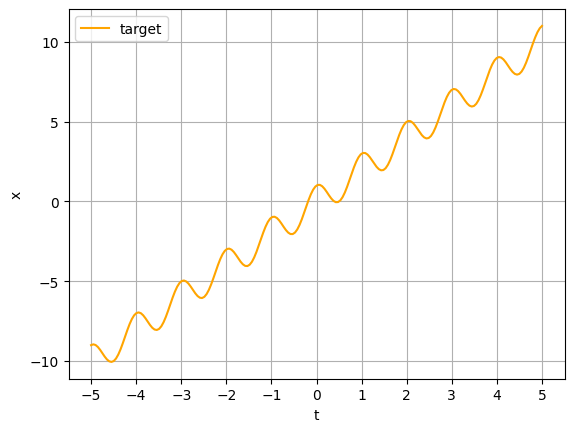

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

#  plot the trajectory
data = np.load("q2_a_data.npy") # size: 200*2, the first column is time input while the second column is x-coordinate.
t = data[:, 0] # Column 0 - time.
target = data[:, 1] # Column 1 - x-coordinate.

plt.plot(t, target, label='target', color='orange')
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(1))  # tick interval = 1 - readability.
plt.legend()
plt.grid()
plt.xlabel("t")
plt.ylabel("x")
plt.show()


### Results and Interpretation

Analysing the trajectory in the first figure it shows characteristics of a linear correlation, and Sine and Cosine due to the consistent and similar waves.

Due to this anaysis a bias, linear, sine, and cosine functions were made to predict the trajectory. We can see in the final plot that this analysis was correct.

MSE - Mean Squared Error - Metric to calculate the accuracy of Linear Regression.

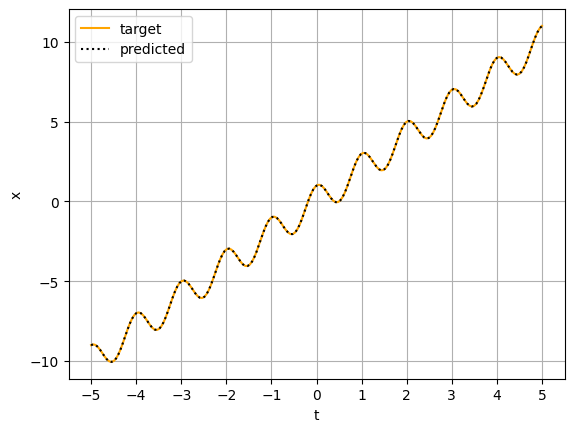

MSE: 4.932089920456967e-31


In [58]:
# Period = 2pi / K
# 1 = 2pi / K
# K = 2pi
def design_matrix(x):
    return np.column_stack([
        np.ones_like(x), 
        x,
        np.sin(2*np.pi*x),
        np.cos(2*np.pi*x)
    ])
    
X = design_matrix(t)

w = fit_linear_regression(t, target, X)
t_pred = predict_linear_regression(X, w)

plt.plot(t, target, label='target', color='orange')
plt.plot(t, t_pred, label='predicted', linestyle='dotted', color='black')
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(1))  # tick interval = 1 - readability.
plt.legend()
plt.grid()
plt.xlabel("t")
plt.ylabel("x")
plt.show()

# Calculate MSE
mse = np.mean((target - t_pred) ** 2)
print(f"MSE: {mse}")


**Q2 b (5 marks)**

Similar to Q2 a, please read data from "q2_b_data.npy", and do the following:

1. Choose and implement your basis function combination. You may decide whether to include a bias term depending on your fitting performance.
2. Plot your prediction and the original data in the same figure (i.e., t-x).
3. Calculate and report the Mean Squared Error (MSE) for your fit.
4. Justify your choice of basis functions.

Include clear titles, axis labels, and legends for all figures.

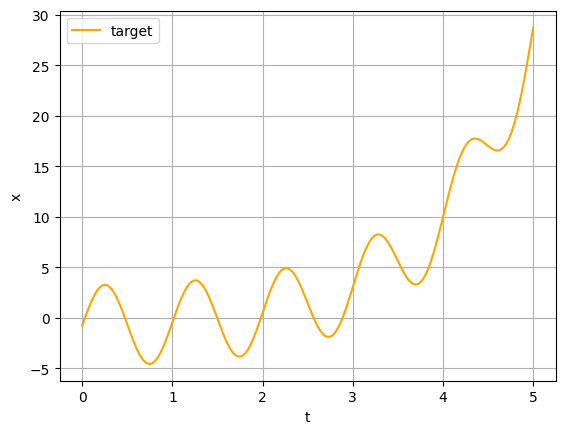

In [59]:
#  plot the trajectory
data = np.load("q2_b_data.npy") # size: 200*2, the first column is time input while the second column is x-coordinate.
t = data[:, 0]
target = data[:, 1]

plt.plot(t, target, label='target', color='orange')
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(1))  # tick interval = 1
plt.legend()
plt.grid()
plt.xlabel("t")
plt.ylabel("x")
plt.show()

### Results and Interpretation

Analysing the shape of the trajectory, it appears to show exponential characteristics because of the steep curve, and Sine and Cosine due to the repeated similar shaped waves. 

Due to this anaylsis a bias, exponential, sine, and cosine basis functions were made to predict the trajectory. We can see in the final plot that this analysis is correct.

MSE - Mean Squared Error - Metric to calculate the accuracy of Linear Regression.

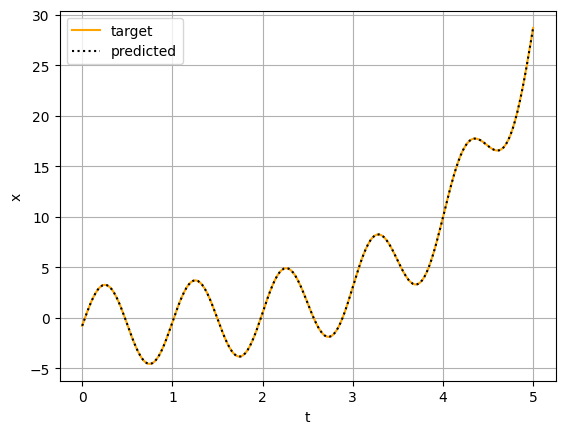

MSE: 4.691072306461543e-30


In [60]:
# Sine, Cosine, and Exponential.
def design_matrix(x):
    return np.column_stack([
        np.ones_like(x), # Bias
        np.exp(x), # Exponential
        np.sin(2*np.pi*x), # Sine
        np.cos(2*np.pi*x) # Cosine
    ])
    
X = design_matrix(t)

w = fit_linear_regression(t, target, X)
t_pred = predict_linear_regression(X, w)

plt.plot(t, target, label='target', color='orange')
plt.plot(t, t_pred, label='predicted', linestyle='dotted', color='black')
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(1))  # tick interval = 1 - readability.
plt.legend()
plt.grid()
plt.xlabel("t")
plt.ylabel("x")
plt.show()

# Calculate MSE
mse = np.mean((target - t_pred) ** 2)
print(f"MSE: {mse}")

# Question 3

**Q3 a (4 marks)**

You are given a data array called "shape_array.npy" that comprises 7 samples organised as columns in the array, where each column corresponds to one sample. The data format in each column is: [x_1, y_1, z_1, x_2, y_2, z_2, ………, x_N, y_N, z_N], where (x_i, y_i, z_i) corresponds to the i-th 3D point of a blood vessel. By plotting all 3D points in one column, you can obtain the shape of a blood vessel of that sample.

Plot seven figures to show the 3D blood vessel shape for each sample separately. Also plot two arbitrary shapes on top of each other to get a feeling of how similar or dissimilar the shapes are.

Shape:  (1845, 7)  Head:  [0.00186122 0.00312417 0.00041169 0.00229733 0.00120909 0.00230087
 0.00234746]


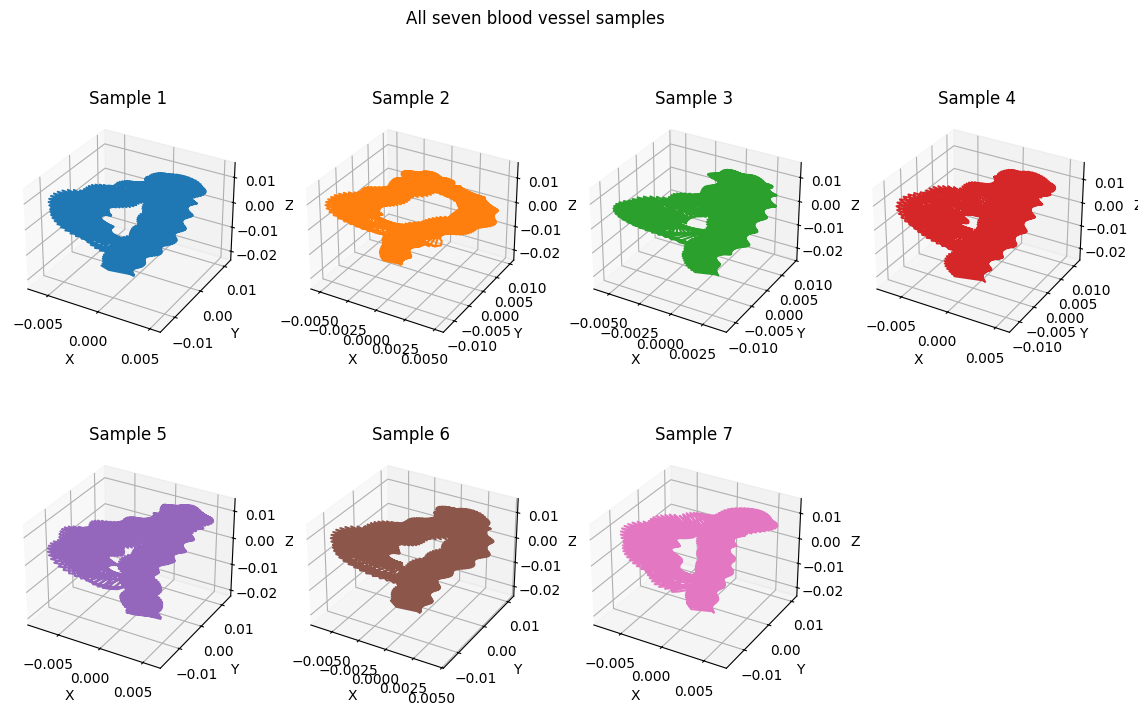

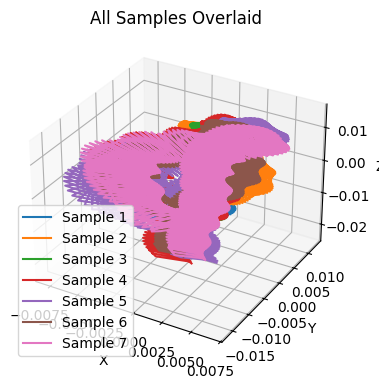

In [61]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Import the 3D plotting toolkit
import numpy as np

data = np.load("shape_array.npy")
print("Shape: ", data.shape, " Head: ", data[0])

# Samples
fig_1, ax_1 = plt.subplots(2, 4, subplot_kw=dict(projection='3d'), figsize=(14, 8))
fig_1.suptitle("All seven blood vessel samples")
ax_1 = ax_1.flatten()
# Overlaid
fig_2 = plt.figure(figsize=(14, 8))
ax_2 = fig_2.add_subplot(241, projection='3d') # 1 row, 1 column, 3D plot.

for i in range(data.shape[1]):
    sample = data[:, i] # All rows, column i.
    x = sample[0::3] # 0, 3, 6, 9, ...
    y = sample[1::3] # 1, 4, 7, 10, ...
    z = sample[2::3] # 2, 5, 8, 11, ...
    colour = plt.cm.tab10(i) # Colour for each sample.

    ax_2.plot(x, y, z, color=colour, label=f"Sample {i+1}")

    ax_1[i].plot(x, y, z, color=colour)
    ax_1[i].set_title(f"Sample {i+1}")
    ax_1[i].set_xlabel("X")
    ax_1[i].set_ylabel("Y")
    ax_1[i].set_zlabel("Z")

ax_1[7].set_visible(False) # Hide the last graph from the grid (only 7 samples).

ax_2.set_title("All Samples Overlaid")
ax_2.set_xlabel("X")
ax_2.set_ylabel("Y")
ax_2.set_zlabel("Z")
ax_2.legend()
plt.tight_layout()
plt.show()

**Q3 b (10 marks)** 

Next, perform eigendecomposition of the covariance matrix estimated from the given data array. Finally, project original data onto lower-dimensional space and reconstruct data.

Proceed as follows:

1. Subtract the mean from the data, so that it is centered around the origin.

2. Estimate the covariance matrix from the centred data.

3. Calculate eigenvectors and eigenvalues using numpy functions

4. Project centered data (1845 dimension) into 5 dimension. 

5. Reconstruct the blood vessel shape from the lower dimension data in step 4.


As a sanity check plot a blood vessel shape reconstructed from the eigenvectors on top of the original blood vessel shape. Comment on your results.

### Results and Interpretation

Here we go through the steps of dimention reduction. 
- First we centralise the data so that the PCA is refering to the correct origin of the data. 
- Then we find the covariance matrix to capture the shape and orientation of the data. 
- Eigenvalues and eigenvectors are calculated. 
- These values are then used to project the data turning 1845 dimensions into 5 dimensions. This is done to simplify the complex dataset whilst retaining the most important information. 
- The data is then reconstructed as a sanity check to show the alterations we have made to the data. 
- Plotting the original against the reconstructed data can give a good visualisation of the variance between the original and reconstructed data.

Eigenvalues - How much variance in the direction of a Eigenvector.
Eigenvector - Directiion of variance.

The plots below show the original blood vessel, the reconstructed vessel, and an overlay of both.

Eigenvalues:  [-9.56945347e-19 -6.58404665e-19 -6.24071711e-19 ...  1.43924451e-04
  3.83298015e-04  1.13989731e-03]
Projected data shape:  (5, 7)
Fraction of variance retained:  0.9937869562757634


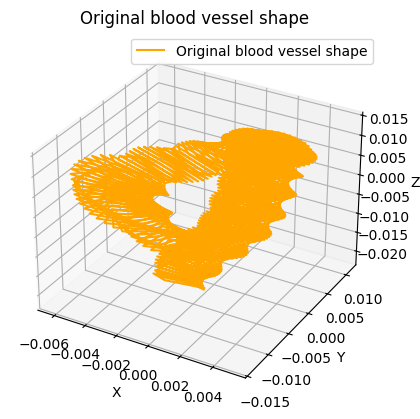

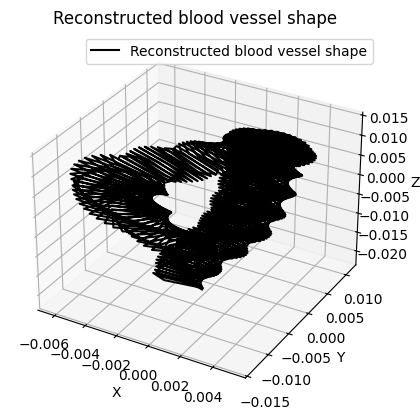

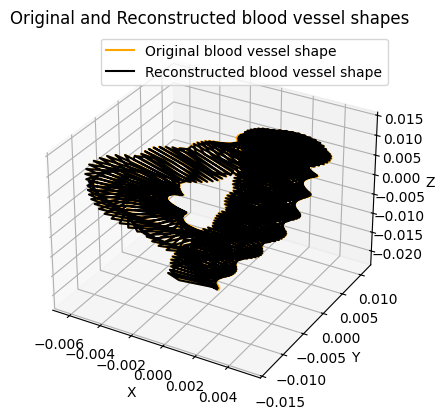

In [74]:
# Subtract the mean from the data, so that it is centered around the origin.
mean_shape = np.mean(data, axis=1, keepdims=True)
centered_data = data - mean_shape

# Estimate the covariance matrix from the centred data.
cov_matrix = np.cov(centered_data) # Covariance matrix. - (1845, 1845)

# Calculate eigenvectors and eigenvalues using numpy functions.
eigvalues, eigvecs = np.linalg.eigh(cov_matrix) # Eigenvalues and eigenvectors. - (1845,) and (1845, 1845)
print('Eigenvalues: ', eigvalues)

# Sort the eigenvalues in descending order.
idx = np.argsort(eigvalues)[::-1]
eigvalues = eigvalues[idx]
eigvecs = eigvecs[:, idx]

# Project centered data (1845 dimension) into 5 dimension.
projected_data = eigvecs[:, :5].T @ centered_data # (5, 7)
print('Projected data shape: ', projected_data.shape)

# Reconstruct the blood vessel shape from the lower dimension data in step 4.
reconstructed_data_one = eigvecs[:, :5] @ projected_data + mean_shape

# Fraction of variance retained.
fraction_variance_retained = np.sum(eigvalues[:5]) / np.sum(eigvalues)
print('Fraction of variance retained: ', fraction_variance_retained)

# Plot the data.
vessel_shape = data[:, 0]
x = vessel_shape[0::3]
y = vessel_shape[1::3]
z = vessel_shape[2::3]
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(x, y, z, label='Original blood vessel shape', color='orange')
ax.set_title('Original blood vessel shape')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.show()

# Plot the reconstructed data.
vessel_shape = reconstructed_data_one[:, 0]
x_reconstructed_one = vessel_shape[0::3]
y_reconstructed_two = vessel_shape[1::3]
z_reconstructed_three = vessel_shape[2::3]
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(x_reconstructed_one, y_reconstructed_two, z_reconstructed_three, label='Reconstructed blood vessel shape', color='black')
ax.set_title('Reconstructed blood vessel shape')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.show()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(x, y, z, label='Original blood vessel shape', color='orange')
ax.plot(x_reconstructed_one, y_reconstructed_two, z_reconstructed_three, label='Reconstructed blood vessel shape', color='black')
ax.set_title('Original and Reconstructed blood vessel shapes')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.show()

**Q3 c (4 marks)** 

Research PCA analysis using the *scikit-learn* library. Perform PCA analysis and show the reconstructed data of any blood vessel shape on top of the original blood vessel shape. There are variables in the PCA object that correspond to the eigenvalues used for choosing projection eigenvectors. Compare the eigenvalues  and eigenvectors you have computed in the previous question with the eigenvalues  and the eigenvectors computed by the *scikit-learn* library. Compare the reconstructed coordinates from both methods. Comment on your results.

### Results and Interpretation

In this section - alternative to conducting PCA from scratch - we go over how PCA is conducted using sklearn.decomposition.
- First we tranpose the data as sklearn takes the format (n_samples, n_features) and our data (1845, 7) is currently (n_features, n_samples).
- Then the PCA is fit to the transposed data.
- Eigenvalues and eigenvectors are calculated. - a comparison can be made here between vectors and values generated manually compared to generated using sklearn.
- The data is then reconstructed as a sanity check to show the alterations sklearn has made to the data. 
- Plotting the original against the reconstructed data can give a good visualisation of the variance between the original and reconstructed data.

RSME - Root Square Mean Error - metric to calculate the average value predicted between the values predicted by the PCA.

The plots below show the original blood vessel, the reconstructed vessel from scratch, the reconstructed vessel using sklearn and an overlay of the original, scratch reconstructed and sklearn reconstructed.

RMSE:  7.704046491991817e-10


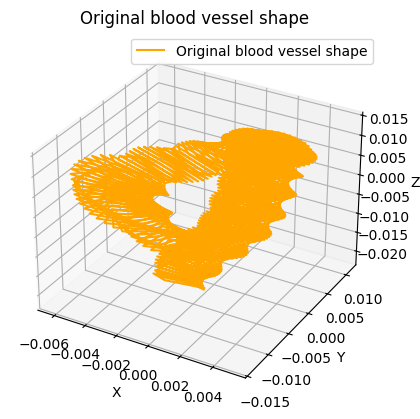

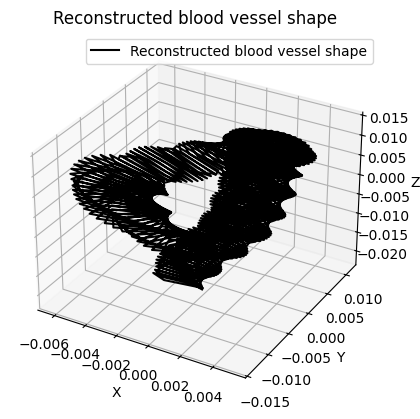

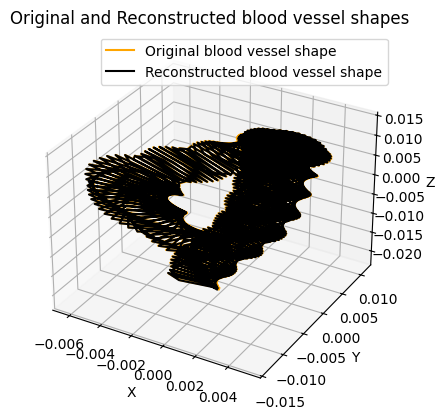

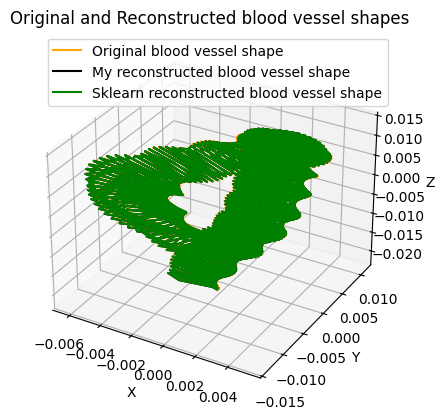

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Import the 3D plotting toolkit

# sklearn format = (n_samples, n_features)
# my format = (n_features, n_samples)
transposed_data = data.T

# sklearn PCA
pca = PCA(n_components=5)
projected_data = pca.fit_transform(transposed_data) 

# Get the eigenvalues and eigenvectors.
eigvalues = pca.explained_variance_
eigvects = pca.components_

# Reconstruct the data.
reconstructed_data = pca.inverse_transform(projected_data)
reconstructed_data = reconstructed_data.T

#rmse
rmse = np.sqrt(np.mean((reconstructed_data_one - reconstructed_data) ** 2))
print('RMSE: ', rmse)

# Plot the data.
vessel_shape = data[:, 0]
x = vessel_shape[0::3]
y = vessel_shape[1::3]
z = vessel_shape[2::3]
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(x, y, z, label='Original blood vessel shape', color='orange')
ax.set_title('Original blood vessel shape')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.show()

# Plot the reconstructed data.
vessel_shape = reconstructed_data[:, 0]
x_reconstructed = vessel_shape[0::3]
y_reconstructed = vessel_shape[1::3]
z_reconstructed = vessel_shape[2::3]
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(x_reconstructed, y_reconstructed, z_reconstructed, label='Reconstructed blood vessel shape', color='black')
ax.set_title('Reconstructed blood vessel shape')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.show()

# Plot the original and reconstructed data.
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(x, y, z, label='Original blood vessel shape', color='orange')
ax.plot(x_reconstructed, y_reconstructed, z_reconstructed, label='Reconstructed blood vessel shape', color='black')
ax.set_title('Original and Reconstructed blood vessel shapes')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.show()

# Plot the original against my reconstructed data and sklearn reconstructed data.
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(x, y, z, label='Original blood vessel shape', color='orange')
ax.plot(x_reconstructed_one, y_reconstructed_two, z_reconstructed_three, label='My reconstructed blood vessel shape', color='black')
ax.plot(x_reconstructed, y_reconstructed, z_reconstructed, label='Sklearn reconstructed blood vessel shape', color='green')
ax.set_title('Original and Reconstructed blood vessel shapes')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.show()
